# Mini-Project 1: UBOS District Population Forecaster

**Scenario.** A district planning unit needs 5-year population forecasts (2025–2029) to plan primary-school classrooms.
Populations are in **thousands** (illustrative UBOS-style estimates, 2015–2024).

All reusable logic lives in `src/population/` (domain class, forecasters, validation, planning, plotting) and the
shared `src/core/` package (forecasting base class, metrics, statistics). This notebook orchestrates and interprets.

**Assumptions**
* The five series are equally spaced annual estimates with no revisions; Kampala, Wakiso and Gulu come from the brief.
* Mbarara and Arua are *illustrative* additions (see `src/population/data.py`): Mbarara adds a roughly constant number of
  people per year (linear growth), Arua has a growth spurt in 2016–2018 (refugee influx) followed by slower growth, which
  is a structural break that tests the models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.core.plotting import apply_style
from src.population import (
    ClassroomPlan, DistrictPopulation, ExponentialCAGRForecaster, FibonacciRatioForecaster,
    LinearTrendForecaster, forecast_district, validate_models,
)
from src.population.data import load_districts
from src.population.plotting import plot_forecasts

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SEED = 2026
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

## 1. The `DistrictPopulation` class

The class stores years and populations as **read-only** NumPy arrays and validates on construction (equal lengths, no
negatives, non-empty, consecutive years). It implements `__repr__`, `__len__`, `__iter__` and `__eq__`.

In [2]:
districts = load_districts()
for d in districts:
    print(repr(d), "| len =", len(d))

DistrictPopulation(name='Kampala', years=2015-2024, n=10, latest=1,800k) | len = 10
DistrictPopulation(name='Wakiso', years=2015-2024, n=10, latest=1,670k) | len = 10
DistrictPopulation(name='Gulu', years=2015-2024, n=10, latest=480k) | len = 10
DistrictPopulation(name='Mbarara', years=2015-2024, n=10, latest=610k) | len = 10
DistrictPopulation(name='Arua', years=2015-2024, n=10, latest=1,105k) | len = 10


In [3]:
# Validation in action: every bad input is rejected with an informative message.
bad_inputs = {
    "unequal lengths": ([2020, 2021, 2022], [10, 20]),
    "negative value": ([2020, 2021], [10, -5]),
    "empty": ([], []),
}
for label, (years, pops) in bad_inputs.items():
    try:
        DistrictPopulation("Bad", years, pops)
    except ValueError as err:
        print(f"{label:>16}: ValueError -> {err}")

 unequal lengths: ValueError -> years (3) and populations (2) differ in length
  negative value: ValueError -> populations cannot be negative
           empty: ValueError -> a district needs at least one observation


## 2. Descriptive statistics: `statistics` vs NumPy

In [4]:
rows = []
for d in districts:
    s, n0, n1 = d.statistics_summary(), d.numpy_summary(ddof=0), d.numpy_summary(ddof=1)
    rows.append({"district": d.name, "mean": s.mean, "median": s.median,
                 "statistics.variance": s.variance, "np.var (ddof=0)": n0.variance, "np.var (ddof=1)": n1.variance,
                 "statistics.stdev": s.stdev, "np.std (ddof=0)": n0.stdev})
stats_df = pd.DataFrame(rows).set_index("district")
stats_df

,mean,median,statistics.variance,np.var (ddof=0),np.var (ddof=1),statistics.stdev,np.std (ddof=0)
district,,,,,,,
Kampala,"1,477.000","1,460.000","42,601.111","38,341.000","42,601.111",206.400,195.809
Wakiso,"1,280.000","1,260.000","60,066.667","54,060.000","60,066.667",245.085,232.508
Gulu,389.500,382.500,"2,885.833","2,597.250","2,885.833",53.720,50.963
Mbarara,539.600,539.500,"2,221.156","1,999.040","2,221.156",47.129,44.711
Arua,962.500,990.000,"13,206.944","11,886.250","13,206.944",114.921,109.024


In [5]:
# Check: the ratio of the two variances is exactly n / (n - 1) = 10/9.
ratio = stats_df["statistics.variance"] / stats_df["np.var (ddof=0)"]
print(ratio.round(6).to_dict(), "expected", round(10 / 9, 6))

{'Kampala': 1.111111, 'Wakiso': 1.111111, 'Gulu': 1.111111, 'Mbarara': 1.111111, 'Arua': 1.111111} expected 1.111111


**Why the variances differ.** `statistics.variance` is the **sample** variance, dividing the sum of squared deviations
by $n-1$. `np.var` defaults to the **population** variance, dividing by $n$. `ddof` ("delta degrees of freedom") sets
the denominator to $n - \text{ddof}$: `np.var(x, ddof=1)` reproduces `statistics.variance`, and the ratio of the two is
exactly $n/(n-1) = 10/9$ as shown above. Using $n-1$ (Bessel's correction) makes the variance estimate unbiased when the
mean itself is estimated from the same data. Means and medians agree exactly.

There is also a caveat. These series are *trending*, so the "variance" here mostly measures how much the population
grew over the decade, not random variability around a stable level. It is a descriptive number, not a measure of risk.

## 3. Growth rates and CAGR

$$g_t = \frac{P_t - P_{t-1}}{P_{t-1}}, \qquad \text{CAGR} = \left(\frac{P_{2024}}{P_{2015}}\right)^{1/9} - 1$$

In [6]:
growth = pd.DataFrame({d.name: d.growth_rates() * 100 for d in districts},
                      index=[f"{y-1}→{y}" for y in districts[0].years[1:]]).T
growth["mean YoY %"] = growth.mean(axis=1)
growth["CAGR %"] = [d.cagr() * 100 for d in districts]
growth.sort_values("CAGR %", ascending=False).round(2)

,2015→2016,2016→2017,2017→2018,2018→2019,2019→2020,2020→2021,2021→2022,2022→2023,2023→2024,mean YoY %,CAGR %
Wakiso,5.260,7.000,7.480,6.090,6.560,6.920,6.470,6.080,6.370,6.470,6.470
Kampala,4.170,4.000,3.850,5.190,5.630,5.330,4.430,4.240,4.650,4.610,4.610
Gulu,3.120,4.550,4.350,4.170,4.000,5.130,4.880,5.810,5.490,4.610,4.610
Arua,3.210,6.830,8.140,4.840,3.080,2.490,2.430,2.370,2.310,3.970,3.950
Mbarara,3.400,2.670,3.610,2.710,3.200,2.550,3.020,2.590,2.690,2.940,2.940


In [7]:
# Cross-check CAGR against the compounded mean growth and a hand calculation for Wakiso.
wakiso = next(d for d in districts if d.name == "Wakiso")
print(f"Wakiso CAGR (class) = {wakiso.cagr():.5f}; by hand (1670/950)**(1/9)-1 = {(1670/950)**(1/9)-1:.5f}")
fastest = max(districts, key=lambda d: d.cagr())
print(f"Fastest relative growth: {fastest.name} at {fastest.cagr():.2%} per year")

Wakiso CAGR (class) = 0.06469; by hand (1670/950)**(1/9)-1 = 0.06469
Fastest relative growth: Wakiso at 6.47% per year


**Wakiso grows fastest in relative terms** (CAGR ≈ 6.5 %/yr). It is Kampala's peri-urban belt and absorbs most of the
metropolitan spill-over. Kampala and Gulu have almost identical CAGRs (≈ 4.6 %) despite a four-fold difference in size,
which shows why relative rates, not absolute increments, are the right basis for comparison. Mbarara's YoY rate
*declines* over time. That is the signature of a constant absolute increment (linear growth) on a rising base.

## 4. Forecasting models

All models subclass the abstract `Forecaster` (`src/core/forecasting.py`), which exposes `fit(values, times)` and
`predict(horizon)` and implements validation once (template-method pattern):

| Model | Class | Forecast for step $k$ ahead |
|---|---|---|
| Linear trend | `LinearTrendForecaster` (shared with Project 5) | $\hat P_{T+k} = a + b\,(T+k)$ via `np.polyfit` |
| Exponential / CAGR | `ExponentialCAGRForecaster` | $\hat P_{T+k} = P_T (1+g)^k$ |
| Fibonacci ratio | `FibonacciRatioForecaster` | $\hat P_{T+k} = P_T \prod_{j=1}^{k} F_{j+1}/F_j$ |

In [8]:
fib = FibonacciRatioForecaster()
print("Fibonacci ratios applied for k = 1..8:", fib.ratios(8).round(3))
print("Cumulative multiplier after 5 steps:", np.prod(fib.ratios(5)))
MODEL_FACTORIES = [LinearTrendForecaster, ExponentialCAGRForecaster, FibonacciRatioForecaster]
MODEL_NAMES = [f().name for f in MODEL_FACTORIES]

Fibonacci ratios applied for k = 1..8: [1.    2.    1.5   1.667 1.6   1.625 1.615 1.619]
Cumulative multiplier after 5 steps: 8.0


## 5. Validate before forecasting: train 2015–2021, test 2022–2024

Each model is fitted on 2015–2021 only and scored on the three held-out years (MAE, RMSE and MAPE;
Hyndman & Koehler, 2006). The best model is chosen by **RMSE**,
which penalises large misses and suits capacity planning, where a large shortfall costs more than several small ones.
We also check whether MAE and MAPE agree with that choice.

In [9]:
reports = [validate_models(d, MODEL_FACTORIES, last_train_year=2021) for d in districts]
for rep in reports:
    table = pd.DataFrame(rep.table()).set_index("model")
    print(f"\n=== {rep.district.name}: best = {rep.best.model_name} (metrics agree: {rep.metrics_agree()}) ===")
    display(table.round(2))


=== Kampala: best = Exponential (CAGR) (metrics agree: True) ===


,MAE (k),RMSE (k),MAPE (%)
model,,,
Linear trend,37.620,38.970,2.170
Exponential (CAGR),9.620,10.390,0.550
Fibonacci ratio,"1,483.330","1,890.510",83.770



=== Wakiso: best = Exponential (CAGR) (metrics agree: True) ===


,MAE (k),RMSE (k),MAPE (%)
model,,,
Linear trend,49.400,52.370,3.090
Exponential (CAGR),6.800,8.050,0.420
Fibonacci ratio,"1,266.670","1,604.390",77.620



=== Gulu: best = Exponential (CAGR) (metrics agree: True) ===


,MAE (k),RMSE (k),MAPE (%)
model,,,
Linear trend,18.570,20.290,4.010
Exponential (CAGR),9.440,10.870,2.020
Fibonacci ratio,378.330,481.710,80.370



=== Mbarara: best = Linear trend (metrics agree: True) ===


,MAE (k),RMSE (k),MAPE (%)
model,,,
Linear trend,1.050,1.080,0.180
Exponential (CAGR),2.350,3.000,0.390
Fibonacci ratio,541.000,692.570,89.520



=== Arua: best = Exponential (CAGR) (metrics agree: True) ===


,MAE (k),RMSE (k),MAPE (%)
model,,,
Linear trend,58.040,60.330,5.350
Exponential (CAGR),50.830,55.530,4.670
Fibonacci ratio,996.670,"1,278.180",90.920


In [10]:
summary = pd.DataFrame([{ "district": r.district.name, "best model": r.best.model_name,
                          "RMSE (k)": r.best.rmse, "MAPE %": r.best.mape, "all metrics agree": r.metrics_agree()}
                        for r in reports]).set_index("district")
summary.round(2)

,best model,RMSE (k),MAPE %,all metrics agree
district,,,,
Kampala,Exponential (CAGR),10.390,0.550,True
Wakiso,Exponential (CAGR),8.050,0.420,True
Gulu,Exponential (CAGR),10.870,2.020,True
Mbarara,Linear trend,1.080,0.180,True
Arua,Exponential (CAGR),55.530,4.670,True


## 6. Forecast 2025–2029 with the selected model (+ 95 % bootstrap intervals, extension)

The selected model is **refitted on all ten years** and projected five years ahead. Prediction intervals come from a
residual bootstrap with 1,000 resamples (`bootstrap_interval`;
Efron & Tibshirani, 1993; Hyndman & Athanasopoulos, 2021, §5.5). The bootstrap resamples in-sample residuals to perturb
the history (parameter uncertainty), refits the model, and adds fresh resampled residuals to each future step (shock
uncertainty).

In [11]:
rng = np.random.default_rng(SEED)
factory_by_name = dict(zip(MODEL_NAMES, MODEL_FACTORIES))
forecasts, full_models = {}, {}
for rep in reports:
    fc, model = forecast_district(rep.district, factory_by_name[rep.best.model_name], horizon=5,
                                  n_bootstrap=1000, level=0.95, rng=rng)
    forecasts[rep.district.name], full_models[rep.district.name] = fc, model

fc_table = pd.DataFrame({name: fc.point for name, fc in forecasts.items()}, index=forecasts["Kampala"].years).T
fc_table["95% PI 2029"] = [f"{fc.lower[-1]:,.0f} – {fc.upper[-1]:,.0f}" for fc in forecasts.values()]
fc_table.round(0)

,2025,2026,2027,2028,2029,95% PI 2029
Kampala,"1,883.000","1,970.000","2,060.000","2,155.000","2,255.000","2,207 – 2,297"
Wakiso,"1,778.000","1,893.000","2,015.000","2,146.000","2,285.000","2,254 – 2,311"
Gulu,502.000,525.000,549.000,575.000,601.000,586 – 618
Mbarara,625.000,641.000,656.000,672.000,687.000,685 – 690
Arua,"1,149.000","1,194.000","1,241.000","1,290.000","1,341.000","1,233 – 1,453"


In [12]:
var_rows = []
for d in districts:
    fc = forecasts[d.name]
    var_rows.append({"district": d.name,
                     "var(actual 2015–24)": d.statistics_summary().variance,
                     "var(forecast 2025–29)": float(np.var(fc.point, ddof=1)),
                     "var(detrended residuals)": float(np.var(full_models[d.name].residuals(), ddof=1)),
                     "mean annual increase: actual": float(np.mean(np.diff(d.populations))),
                     "mean annual increase: forecast": float(np.mean(np.diff(np.r_[d.populations[-1], fc.point])))})
var_df = pd.DataFrame(var_rows).set_index("district")
var_df["forecast / actual variance"] = var_df["var(forecast 2025–29)"] / var_df["var(actual 2015–24)"]
var_df.round(2)

,var(actual 2015–24),var(forecast 2025–29),var(detrended residuals),mean annual increase: actual,mean annual increase: forecast,forecast / actual variance
district,,,,,,
Kampala,"42,601.110","21,607.680",98.750,66.670,90.950,0.510
Wakiso,"60,066.670","40,131.360",30.900,80.000,122.930,0.670
Gulu,"2,885.830","1,536.550",13.820,17.780,24.250,0.530
Mbarara,"2,221.160",605.570,0.740,15.560,15.490,0.270
Arua,"13,206.940","5,779.800",691.290,36.110,47.180,0.440


**Interpreting the variance comparison.** Here the variance of a trending series mostly measures **how much the level
changes across the window**. It depends on the window length and the growth speed, not on noise. The forecast
variance is lower for three reasons:

1. **Shorter window.** Five points instead of ten. For a straight line, variance scales with the square of the
   time span, so halving the window roughly quarters it even if the slope is unchanged.
2. **No noise.** A point forecast is a smooth curve with no year-to-year irregularity. The actual series carries a
   residual component (last-but-one column) that the forecast deliberately omits.
3. **Faster growth.** For the four CAGR districts the forecast adds *more* people per year than the history did (last
   two columns), because the CAGR model compounds on a higher base; Mbarara's linear forecast keeps the same increment. That pushes the forecast variance up and partly offsets 1 and 2.

A lower forecast variance therefore does not indicate lower uncertainty about the future. Forecast uncertainty is
measured by the prediction interval, which widens with the horizon.

## 7. Actual, fitted and forecast values

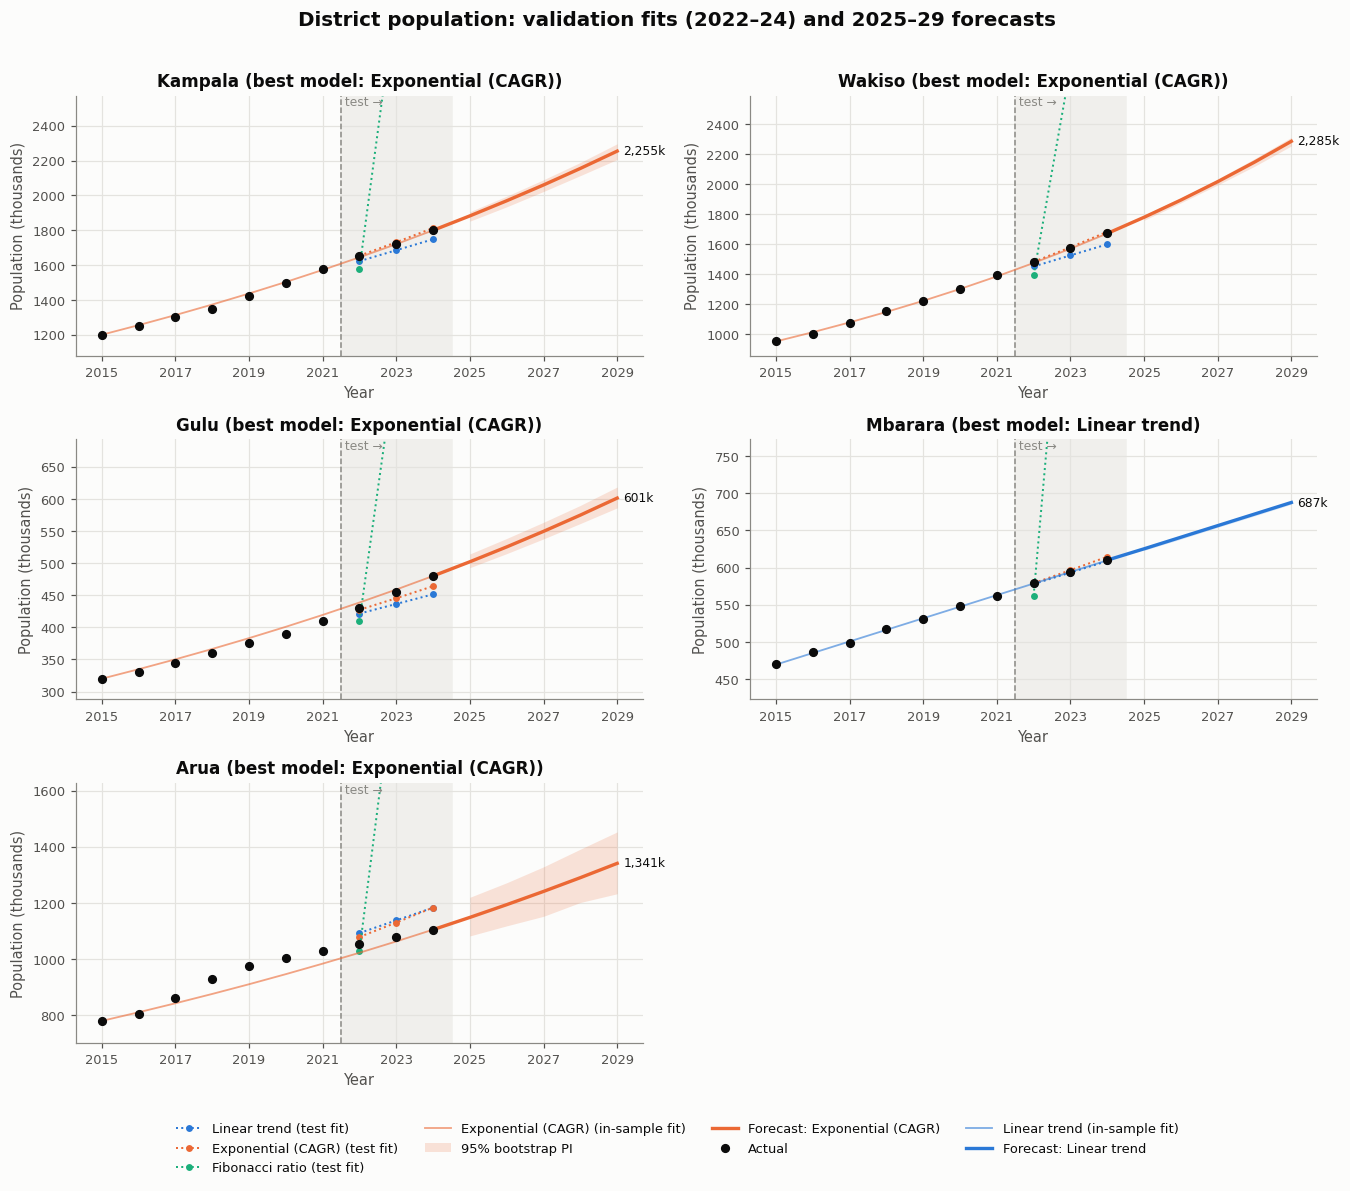

In [13]:
fig = plot_forecasts(reports, forecasts, full_models, MODEL_NAMES)
fig.savefig(FIG_DIR / "p1_population_forecasts.png", bbox_inches="tight")
plt.show()

The dotted lines are each model's 2022–24 test predictions (trained on 2015–21), the shaded band is the test period, and
the solid line plus band is the final 2025–29 forecast with its 95 % bootstrap interval. The Fibonacci test fit is so
far off that it would flatten each panel, so its path is clipped at the top of the axis. The tables above give its size.

## 8. Planning output: additional classrooms by 2029

Assumptions from the brief: 18 % of the population is of primary-school age and a classroom holds 53 pupils.
*Additional* classrooms = classrooms needed for the 2029 cohort minus classrooms needed for the 2024 cohort. This
assumes the 2024 need is already met, which is optimistic in most districts. Both counts are rounded **up**, since you
cannot build a fraction of a classroom and the 53-pupil ceiling is binding.

In [14]:
plans = [ClassroomPlan(d.name, int(d.years[-1]), int(forecasts[d.name].years[-1]),
                       float(d.populations[-1]), forecasts[d.name].final_value, 0.18, 53) for d in districts]
plan_df = pd.DataFrame([{ "district": p.district, "pupils 2024": p.base_pupils, "pupils 2029": p.target_pupils,
                          "classrooms 2024": p.classrooms_base, "classrooms 2029": p.classrooms_target,
                          "additional classrooms": p.additional_classrooms} for p in plans]).set_index("district")
# Range implied by the 95 % prediction interval.
plan_df["additional (95% PI)"] = [
    f"{ClassroomPlan(p.district, 2024, 2029, p.base_population_k, forecasts[p.district].lower[-1], 0.18, 53).additional_classrooms:,}"
    f" – {ClassroomPlan(p.district, 2024, 2029, p.base_population_k, forecasts[p.district].upper[-1], 0.18, 53).additional_classrooms:,}"
    for p in plans]
plan_df.style.format({"pupils 2024": "{:,.0f}", "pupils 2029": "{:,.0f}", "classrooms 2024": "{:,}",
                      "classrooms 2029": "{:,}", "additional classrooms": "{:,}"})

,pupils 2024,pupils 2029,classrooms 2024,classrooms 2029,additional classrooms,additional (95% PI)
district,,,,,,
Kampala,"324,000","405,857","6,114","7,658","1,544","1,381 – 1,687"
Wakiso,"300,600","411,241","5,672","7,760","2,088","1,982 – 2,177"
Gulu,"86,400","108,229","1,631","2,043",412,360 – 470
Mbarara,"109,800","123,742","2,072","2,335",263,255 – 270
Arua,"198,900","241,364","3,753","4,555",802,"434 – 1,182"


In [15]:
# Hand check for Gulu: 2029 pupils = forecast (thousands) * 1000 * 0.18.
g = next(p for p in plans if p.district == "Gulu")
print(f"Gulu: ceil({g.target_population_k:.2f}k*1000*0.18/53) - ceil(480k*1000*0.18/53) = "
      f"{int(np.ceil(g.target_population_k*180/53))} - {int(np.ceil(480*180/53))} = {g.additional_classrooms}")
print("Total additional classrooms across the five districts:", sum(p.additional_classrooms for p in plans))

Gulu: ceil(601.27k*1000*0.18/53) - ceil(480k*1000*0.18/53) = 2043 - 1631 = 412
Total additional classrooms across the five districts: 5109


## Extension: assessment of the Fibonacci-ratio model

The model multiplies the last value by $F_{k+1}/F_k$, which converges to the golden ratio $\varphi \approx 1.618$. It
ignores every observation except the last and imposes a growth path the data never shows: ×1, ×2, ×1.5, … in successive
years, compounding to **×8 in five years**. Hence MAPEs of about 80–90 % on the test years.

*When would it be defensible?* Only if the population obeys the Fibonacci recurrence $N_{t+1} = N_t + N_{t-1}$. This
is Fibonacci's rabbit model (Sigler, 2002): every individual reproduces from its second period onward, no one dies, and resources are
unlimited. In that case growth per period tends to $\varphi$. For a human population growing at rate $g$, one "period"
would have to last $\ln\varphi / \ln(1+g)$ years:

In [16]:
phi = (1 + 5 ** 0.5) / 2
for d in districts:
    print(f"{d.name:>8}: CAGR {d.cagr():.2%} -> one Fibonacci step would equal {np.log(phi)/np.log(1+d.cagr()):5.1f} years")

 Kampala: CAGR 4.61% -> one Fibonacci step would equal  10.7 years
  Wakiso: CAGR 6.47% -> one Fibonacci step would equal   7.7 years
    Gulu: CAGR 4.61% -> one Fibonacci step would equal  10.7 years
 Mbarara: CAGR 2.94% -> one Fibonacci step would equal  16.6 years
    Arua: CAGR 3.95% -> one Fibonacci step would equal  12.4 years


The ratios could only describe these districts if one step lasted **8–17 years**, roughly a generation.
Even then, the ratio would have to be dropped to $\varphi$ from the start (not 1, 2, 1.5, …) and mortality ignored.
At an annual time step we found no growth assumption under which the model is defensible, so it is kept only as a
baseline.

## References

* Efron, B. & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall.
* Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. https://otexts.com/fpp3/
* Hyndman, R. J. & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688.
* NumPy Developers. `numpy.var` documentation. https://numpy.org/doc/stable/reference/generated/numpy.var.html
* Preston, S. H., Heuveline, P. & Guillot, M. (2001). *Demography: Measuring and Modeling Population Processes*. Blackwell.
* Sigler, L. E. (2002). *Fibonacci's Liber Abaci: A Translation into Modern English*. Springer.

## Findings & Limitations

**Findings.** Hold-out validation makes the model choice rest on evidence instead of habit. Constant-percentage (CAGR)
growth wins in four of five districts. On 2022–24 it misses Kampala, Wakiso and Gulu by only 0.4–2.0 % (MAPE), and
MAE, RMSE and MAPE agree every time. Mbarara adds a near-constant ~16,000 people a year, and a linear trend suits it
better (MAPE 0.18 %). The appropriate model therefore depends on how each district grows. The
Fibonacci-ratio model fails everywhere (MAPE 78–91 %) because it imposes ~62 % annual growth regardless of the data.

For planning, the five districts need roughly **5,100 additional classrooms by 2029**. Wakiso (~2,090) and Kampala
(~1,540) account for 70 % of that, even though Kampala is bigger. Wakiso is where growth is fastest. Arua is the
cautionary case: the 2016–18 influx inflated its training trend, so both models overshoot the test years, and its 95 %
interval spans 434–1,182 classrooms. Its programme should be phased and re-forecast every year rather than committed
upfront.

**Limitations.** Each model is estimated from only ten (or seven) annual points. The CAGR model uses only the first and
last observations, so an error in either end-point propagates straight into the forecast. The residual bootstrap
assumes independent residuals. Population residuals are autocorrelated, so the intervals are too narrow (Wakiso's
±30k is almost certainly overconfident). The plan assumes a fixed 18 % school-age share, although fertility decline
and urban age structures will shift it. It also assumes the 2024 need is already met, whereas many Ugandan districts
already exceed 53 pupils per classroom, so the real backlog is larger. The additional districts are illustrative, and
real UBOS projections (which model fertility, mortality and migration explicitly) should replace them before any
budget decision.